In [1]:
import os
import load_dotenv
from load_dotenv import load_dotenv

# This function will load all the variable from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv()

if os.environ.get("CLAUDE_API_KEY"):
    print("CLAUDE API KEY has been loaded")
else:
    raise ValueError("CLAUDE API KEY not found")

if os.environ.get("TAVILY_API_KEY"):
    print("TAVILY API KEY has been loaded")
else:
    raise ValueError("TAVILY API KEY not found")

CLAUDE API KEY has been loaded
TAVILY API KEY has been loaded


In [2]:
from langchain_anthropic import ChatAnthropic

llm_anthropic = ChatAnthropic(
    model = os.environ.get("CLAUDE_MODEL"),
    api_key = os.environ.get('CLAUDE_API_KEY'),
    temperature = 0,
    base_url = os.environ.get("CLAUDE_BASE_URL")
)
llm_anthropic

ChatAnthropic(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-anthropic': '1.5.5'}}, model='vertex_ai.anthropic.claude-opus-4-6', max_tokens=4096, temperature=0.0, anthropic_api_url='https://genai-sharedservice-americas.pwcinternal.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

In [4]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):

    messages_manual: List
    messages_auto: Annotated[List, add] # Using Reducer in Langgraph

In [5]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
# HumanMessage - The Query that is provided to the LLM
# AIMessage - The response generated from the LLM
# SystemMessage - The tone set for the LLM to generate the response

def create_post(state: graph_schema) -> graph_schema:

    messages_manual = state['messages_manual']

    responses_manual = llm_anthropic.invoke(messages_manual).content
    responses_manual_ai = AIMessage(content = responses_manual)

    state['messages_manual'] = messages_manual + [responses_manual_ai]

    messages_auto = state['messages_auto']

    responses_auto = llm_anthropic.invoke(messages_auto).content
    responses_auto_ai = AIMessage(content = responses_auto)

    state['messages_auto'] = [responses_auto_ai]

    return state

def curate_post(state: graph_schema) -> graph_schema:

    messages_manual = state['messages_manual']

    # Append a HumanMessage with the curation instruction so the conversation ends with a user message (required by Vertex AI)
    messages_manual = messages_manual + [
        HumanMessage(content = "Curate the above LinkedIn post with a GenZ tone")
    ]

    responses_manual = llm_anthropic.invoke(messages_manual).content
    responses_manual_ai = AIMessage(content = responses_manual)

    state['messages_manual'] = messages_manual + [responses_manual_ai]

    messages_auto = state['messages_auto']

    messages_auto = messages_auto + [
        HumanMessage(content = "Curate the above LinkedIn post with a GenZ tone, for this we're using a reducer")
    ]

    response_auto = llm_anthropic.invoke(messages_auto).content

    response_auto_ai = AIMessage(content = response_auto)
    state['messages_auto'] = [response_auto_ai]

    return state

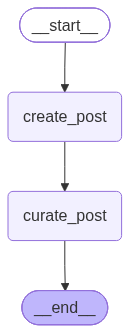

In [7]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

# Adding nodes to the graph
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

# Adding Edges to the graph
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()

Image(messages_graph.get_graph().draw_mermaid_png())
# print(messages_graph.get_graph().draw_mermaid_png())

In [ ]:
messages_graph.invoke(
    {
        "messages_manual": [HumanMessage(content = "The Importance of data privacy in the digital age")],
        "messages_auto": [HumanMessage(content = "The Importance of data privacy in the digital age")]
    }
)